# BERT Bias Classification - Source Domain Diagnosis (v9)

## Objective
Diagnose whether the BERT attention-based bias classifier is learning **bias signals** or **source/style artifacts** on the audited v9 dataset.

### Dataset: bias_sentences_v9.json (10,304 entries)
This dataset is loaded from a single JSON file with an `entries` key. After the audit-correct-reaudit pipeline and counterfactual generation, the v9 source-label composition is:
- **`biased-corpus`** (3,235 entries — 2,066 biased / 1,169 neutral)
- **`gemini`** (4,440 entries — 2,163 biased / 2,277 neutral)
- **`gus-dataset`** (2,629 entries — 1,268 biased / 1,361 neutral)

Each entry carries `pair_id`, `role` (`original` / `counterfactual` / `strengthened` / `relabelled_only`), and `original_id`, so the diagnosis below can split by pair and avoid leakage.

### Features
Uses the precomputed BERT attention feature matrix:
- **`attention_app/bias/extracted_features/feature_matrix_bert_v9.pkl`**
- 3238 numerical attention-derived features plus label metadata

### Methodology
- Pipeline: `VarianceThreshold(0.01) -> StandardScaler -> Classifier`
- Grouping: pair-based groups to avoid leakage between original and counterfactual
- CV: `StratifiedGroupKFold(n_splits=5)`
- Tuning: `HalvingRandomSearchCV`

### Diagnostic Tests
1. **Leave-One-Source-Out (LOSO)**: train on 2 sources, test on the 3rd
2. **Source Classifier**: predict source from the same attention features
3. **Bias Classifier**: full train/test evaluation with pair-based split
4. **Residualization**: regress out source signal, then re-run diagnosis
5. **Error Analysis**: compare errors by source and text type

> **What this notebook reports.** This notebook performs the *source-domain diagnostic* (LOSO, source recoverability, residualization) that motivated the protocol choices for the attention-derived family. It does its own model-selection sweep (LogReg / RandomForest / XGBoost / MLP) with `StratifiedGroupKFold` and `HalvingRandomSearchCV` over a single seed. The **final Table 4 / Table 5 / Appendix B numbers reported in the paper for Attn-BERT are produced by [`02_attention_pipeline/bert_attention_pipeline.ipynb`](../02_attention_pipeline/bert_attention_pipeline.ipynb)** — a multi-seed pipeline (5 seeds, fixed MLP, Platt and Temperature calibration, INLP comparison). The main-test results below agree with the paper within seed variance; the per-source LOSO numbers here are systematically lower because of (a) single-seed variance, (b) model selection / tuning differences, and (c) text-based vs pair-based grouping. Treat the results in this notebook as **diagnostic**, not as the paper's headline numbers.

---


## 1. Setup and Imports

In [1]:
import subprocess
import sys

try:
    import xgboost  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost'])

In [2]:
import json
import os
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GroupShuffleSplit,
    HalvingRandomSearchCV,
    StratifiedGroupKFold,
    cross_validate,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier


def find_root(start: Path, repo_name: str = 'attention-atlas') -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if candidate.name == repo_name:
            return candidate
    return start


# In VS Code Jupyter, __vsc_ipynb_file__ holds the notebook path
_nb_file = Path(globals().get('__vsc_ipynb_file__', '') or '')
if _nb_file.exists():
    root_dir = find_root(_nb_file.parent)
else:
    root_dir = find_root(Path.cwd())
notebook_dir = root_dir / 'dataset' / 'v2'

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f'Root dir: {root_dir}')
print(f'Notebook dir: {notebook_dir}')

Root dir: C:\Users\anoca\Documents\GitHub\attention-atlas
Notebook dir: C:\Users\anoca\Documents\GitHub\attention-atlas\dataset\v2


## 2. Load v9 Dataset from JSON and Validate

Load the dataset from `bias_sentences_v9.json`.
The JSON has a top-level `entries` key with fields: `id, type, text, has_bias, bias_type, bias_description, source, role, original_id, pair_id, topic, sentence_id, edit_spans`.

In [3]:
dataset_path = notebook_dir / 'bias_sentences_v9.json'
with open(dataset_path, encoding='utf-8') as f:
    raw = json.load(f)

df_sentences = pd.DataFrame(raw['entries'])
df_sentences['label'] = df_sentences['has_bias'].astype(int)

# Canonical source names
SOURCE_CANONICAL = {
    'biased_corpus_only': 'biased-corpus',
    'biased_corpus_v2': 'biased-corpus',
    'gemini_only': 'gemini',
    'gemini_only_v2': 'gemini',
    'gus_only': 'gus-dataset',
    'gus_only_v2': 'gus-dataset',
}
df_sentences['source_canonical'] = df_sentences['source'].map(SOURCE_CANONICAL).fillna(df_sentences['source'])

print(f'V9 dataset: {len(df_sentences)} entries')
print(f'Unique texts: {df_sentences["text"].nunique()} / {len(df_sentences)}')
print(f'Label distribution: {df_sentences["label"].value_counts().sort_index().to_dict()}')
print(f'Sources (raw): {df_sentences["source"].value_counts().to_dict()}')
print(f'Sources (canonical): {df_sentences["source_canonical"].value_counts().to_dict()}')

V9 dataset: 10304 entries
Unique texts: 10304 / 10304
Label distribution: {0: 4807, 1: 5497}
Sources (raw): {'gemini_only': 4440, 'biased_corpus_only': 3235, 'gus_only': 2629}
Sources (canonical): {'gemini': 4440, 'biased-corpus': 3235, 'gus-dataset': 2629}


In [4]:
# Cross-source text overlap
source_groups = df_sentences.groupby('source')['text'].apply(set)
source_names = list(source_groups.index)

print('Cross-source text overlap (should be 0):')
for i in range(len(source_names)):
    for j in range(i + 1, len(source_names)):
        overlap = source_groups[source_names[i]] & source_groups[source_names[j]]
        print(f'  {source_names[i]} vs {source_names[j]}: {len(overlap)}')

print('\nBias by source:')
print(pd.crosstab(df_sentences['source_canonical'], df_sentences['label'], margins=True))

print('\nRole distribution:')
print(pd.crosstab(df_sentences['source_canonical'], df_sentences['role'], margins=True))

Cross-source text overlap (should be 0):
  biased_corpus_only vs gemini_only: 0
  biased_corpus_only vs gus_only: 0
  gemini_only vs gus_only: 0

Bias by source:
label                0     1    All
source_canonical                   
biased-corpus     1169  2066   3235
gemini            2277  2163   4440
gus-dataset       1361  1268   2629
All               4807  5497  10304

Role distribution:
role              counterfactual  original  unpaired    All
source_canonical                                           
biased-corpus                956       957      1322   3235
gemini                      2158      2156       126   4440
gus-dataset                  733       731      1165   2629
All                         3847      3844      2613  10304


## 3. Load Feature Matrix

Load the precomputed BERT feature matrix for the v9 dataset and align it with the metadata.

**Note:** if `feature_matrix_bert_v9.pkl` does not yet exist, you need to run the extraction script first:
```bash
python dataset/v2/extract_bert_features.py --dataset-path dataset/v2/bias_sentences_v9.json --output-path attention_app/bias/extracted_features/feature_matrix_bert_v9.pkl
```

In [5]:
features_path = root_dir / 'attention_app' / 'bias' / 'extracted_features' / 'feature_matrix_bert_v9.pkl'
if not features_path.exists():
    raise FileNotFoundError(
        f'Feature matrix not found: {features_path}\n'
        'Run the extraction script first:\n'
        '  python dataset/v2/extract_bert_features.py '
        '--dataset-path dataset/v2/bias_sentences_v9.json '
        '--output-path attention_app/bias/extracted_features/feature_matrix_bert_v9.pkl'
    )

df_features = pd.read_pickle(features_path).copy()
print(f'Feature matrix shape: {df_features.shape[0]} samples x {df_features.shape[1]} columns')

if len(df_features) != len(df_sentences):
    raise RuntimeError(
        f'Size mismatch: feature matrix has {len(df_features)} rows but '
        f'JSON dataset has {len(df_sentences)} rows.'
    )

label_match = np.array_equal(df_features['label'].astype(int).values, df_sentences['label'].values)
print(f'Label alignment with JSON dataset: {label_match}')
if not label_match:
    raise RuntimeError('Feature matrix labels do not align with JSON dataset labels.')

# Attach metadata from JSON
for col in ['text', 'source', 'source_canonical', 'original_id', 'role', 'topic', 'pair_id', 'sentence_id']:
    if col in df_sentences.columns:
        df_features[col] = df_sentences[col].values

print(f'Unique texts after alignment: {df_features["text"].nunique()} / {len(df_features)}')
print(f'Source distribution: {df_features["source_canonical"].value_counts().to_dict()}')

Feature matrix shape: 10304 samples x 3239 columns
Label alignment with JSON dataset: True
Unique texts after alignment: 10304 / 10304
Source distribution: {'gemini': 4440, 'biased-corpus': 3235, 'gus-dataset': 2629}


## 4. Prepare Data for Modeling

In [6]:
drop_cols = [
    'label', 'id', 'text', 'source', 'source_canonical', 'original_id', 'role',
    'topic', 'pair_id', 'sentence_id', 'type', 'validated_source', 'hasbias',
    'has_bias', 'bias_type', 'bias_description', 'edit_spans',
]
X = df_features.drop(columns=[c for c in drop_cols if c in df_features.columns])
y = df_features['label'].astype(int)
sources = df_features['source_canonical'].values

# --- Pair-based groups for leakage-free splitting ---
# Counterfactual pairs (original + CF) MUST stay in the same split.
group_col = df_features['pair_id'].copy()
mask_no_pair = group_col.isna()
group_col[mask_no_pair] = ['unpaired_' + str(i) for i in range(mask_no_pair.sum())]
groups = group_col.values

n_paired = (~mask_no_pair).sum()
n_unpaired = mask_no_pair.sum()
print(f'Total features: {X.shape[1]}')
print(f'Total samples:  {X.shape[0]}')
print(f'Unique groups:  {len(set(groups))}')
print(f'  Paired entries (share pair_id): {n_paired}')
print(f'  Unpaired entries (unique group): {n_unpaired}')
print(f'Label distribution: biased={int(y.sum())}, neutral={int((y == 0).sum())}')

print('\nSource distribution:')
for src, cnt in Counter(sources).most_common():
    src_labels = y[sources == src]
    print(
        f'  {src:18} {cnt:5d} '
        f'(biased={int(src_labels.sum())}, neutral={int((src_labels == 0).sum())})'
    )

# Role distribution
print(f'\nRole distribution: {df_features["role"].value_counts().to_dict()}')

X_final = X.copy()
unique_sources = np.array(sorted(np.unique(sources)))

Total features: 3238
Total samples:  10304
Unique groups:  6460
  Paired entries (share pair_id): 7691
  Unpaired entries (unique group): 2613
Label distribution: biased=5497, neutral=4807

Source distribution:
  gemini              4440 (biased=2163, neutral=2277)
  biased-corpus       3235 (biased=2066, neutral=1169)
  gus-dataset         2629 (biased=1268, neutral=1361)

Role distribution: {'counterfactual': 3847, 'original': 3844, 'unpaired': 2613}


## 5. Leave-One-Source-Out (LOSO) Cross-Validation

Train on 2 sources and test on the held-out source.
This is the same diagnostic Table 6 / Appendix B reports in the paper for the attention-derived family.

In [7]:
print(f'Sources for LOSO: {list(unique_sources)}\n')

loso_results = []

for test_source in unique_sources:
    print('=' * 72)
    print(f'LOSO Fold: Test on [{test_source}]')
    print('=' * 72)

    test_mask = sources == test_source
    train_mask = ~test_mask

    X_train = X_final.iloc[np.where(train_mask)[0]]
    X_test = X_final.iloc[np.where(test_mask)[0]]
    y_train = y.iloc[np.where(train_mask)[0]]
    y_test = y.iloc[np.where(test_mask)[0]]
    groups_train = groups[train_mask]
    train_source_list = np.unique(sources[train_mask])

    print(f'  Train: {len(X_train)} samples from {list(train_source_list)}')
    print(f'  Test:  {len(X_test)} samples from {test_source}')
    print(f'  Train labels: biased={int(y_train.sum())}, neutral={int((y_train == 0).sum())}')
    print(f'  Test  labels: biased={int(y_test.sum())}, neutral={int((y_test == 0).sum())}')

    pipeline = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', XGBClassifier(
            tree_method='approx',
            max_depth=8,
            n_estimators=500,
            learning_rate=0.05,
            min_child_weight=1,
            gamma=0.1,
            reg_alpha=0.1,
            reg_lambda=1.0,
            eval_metric='logloss',
            random_state=RANDOM_STATE,
        )),
    ])

    cv = StratifiedGroupKFold(n_splits=5)
    scoring = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']
    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        groups=groups_train,
    )
    print('\n  Internal CV (train sources):')
    print(f'    AUC:  {cv_scores["test_roc_auc"].mean():.4f} (+/- {cv_scores["test_roc_auc"].std():.4f})')
    print(f'    F1:   {cv_scores["test_f1"].mean():.4f} (+/- {cv_scores["test_f1"].std():.4f})')

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)

    print('\n  Held-out Test Results:')
    print(f'    Accuracy:  {acc:.4f}')
    print(f'    Precision: {prec:.4f}')
    print(f'    Recall:    {rec:.4f}')
    print(f'    F1:        {f1:.4f}')
    print(f'    AUC:       {auc:.4f}')
    print('\n  Confusion Matrix:')
    print(cm)
    print('\n  Classification Report:')
    print(classification_report(y_test, y_pred, zero_division=0))

    loso_results.append({
        'test_source': test_source,
        'train_sources': ', '.join(train_source_list),
        'n_train': len(X_train),
        'n_test': len(X_test),
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'auc': auc,
        'confusion_matrix': cm.tolist(),
    })

Sources for LOSO: ['biased-corpus', 'gemini', 'gus-dataset']

LOSO Fold: Test on [biased-corpus]
  Train: 7069 samples from ['gemini', 'gus-dataset']
  Test:  3235 samples from biased-corpus
  Train labels: biased=3431, neutral=3638
  Test  labels: biased=2066, neutral=1169

  Internal CV (train sources):
    AUC:  0.9562 (+/- 0.0043)
    F1:   0.8825 (+/- 0.0077)

  Held-out Test Results:
    Accuracy:  0.7994
    Precision: 0.8173
    Recall:    0.8833
    F1:        0.8490
    AUC:       0.8760

  Confusion Matrix:
[[ 761  408]
 [ 241 1825]]

  Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.65      0.70      1169
           1       0.82      0.88      0.85      2066

    accuracy                           0.80      3235
   macro avg       0.79      0.77      0.78      3235
weighted avg       0.80      0.80      0.80      3235

LOSO Fold: Test on [gemini]
  Train: 5864 samples from ['biased-corpus', 'gus-dataset']
  Test: 

LOSO SUMMARY
  test_source  n_train  n_test  accuracy  precision   recall       f1      auc
biased-corpus     7069    3235  0.799382   0.817286 0.883349 0.849035 0.876035
       gemini     5864    4440  0.629279   0.650729 0.515950 0.575554 0.678041
  gus-dataset     7675    2629  0.707493   0.639933 0.899842 0.747951 0.824172

Mean across LOSO folds:
accuracy     0.712051
precision    0.702649
recall       0.766381
f1           0.724180
auc          0.792750
dtype: float64


-----------------------------------------------------------------
biased-corpus      |  0.6383 |  0.7994 |  0.6629 |  0.8760
gemini             |  0.4042 |  0.6293 |  0.4095 |  0.6780
gus-dataset        |  0.5488 |  0.7075 |  0.7511 |  0.8242


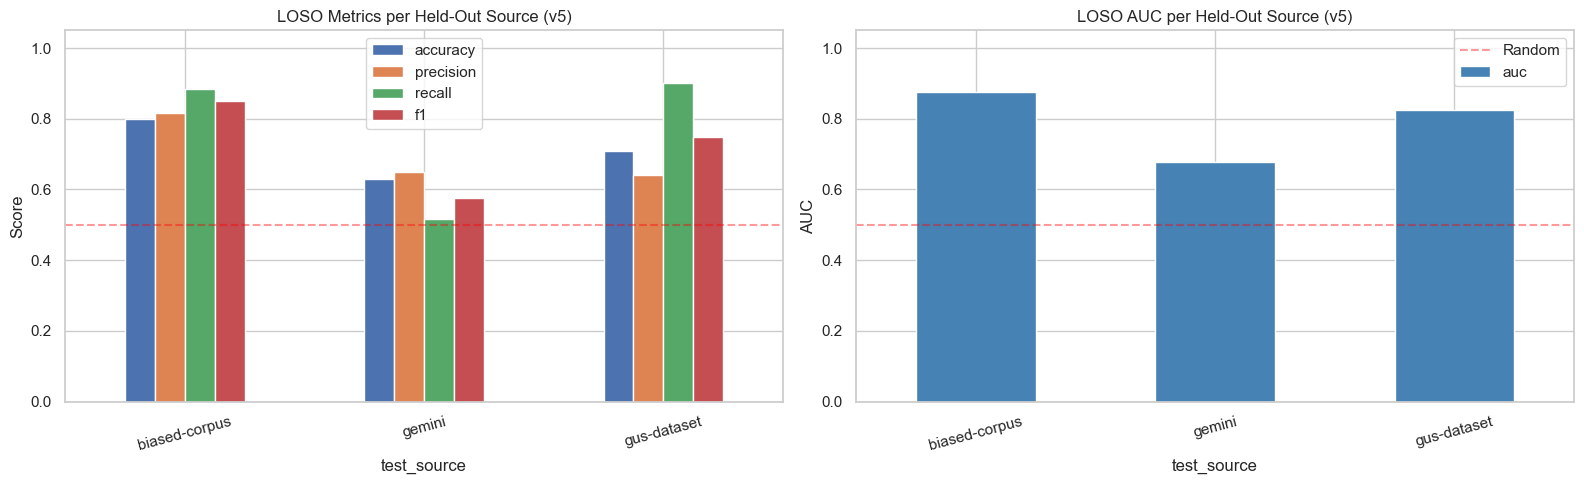

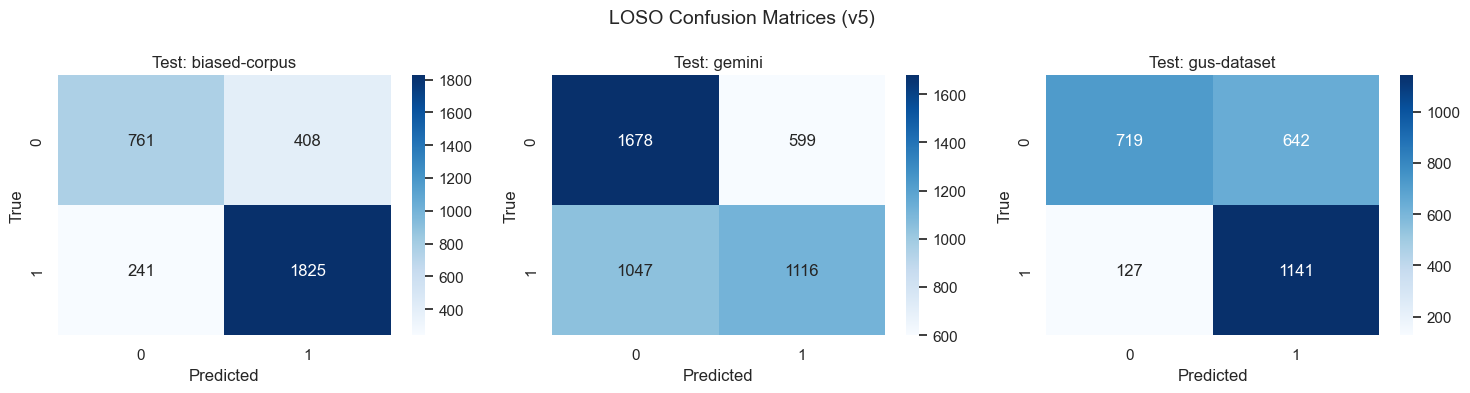

In [8]:
print('=' * 72)
print('LOSO SUMMARY')
print('=' * 72)

df_loso = pd.DataFrame(loso_results)
print(df_loso[['test_source', 'n_train', 'n_test', 'accuracy', 'precision', 'recall', 'f1', 'auc']].to_string(index=False))

print('\nMean across LOSO folds:')
print(df_loso[['accuracy', 'precision', 'recall', 'f1', 'auc']].mean())


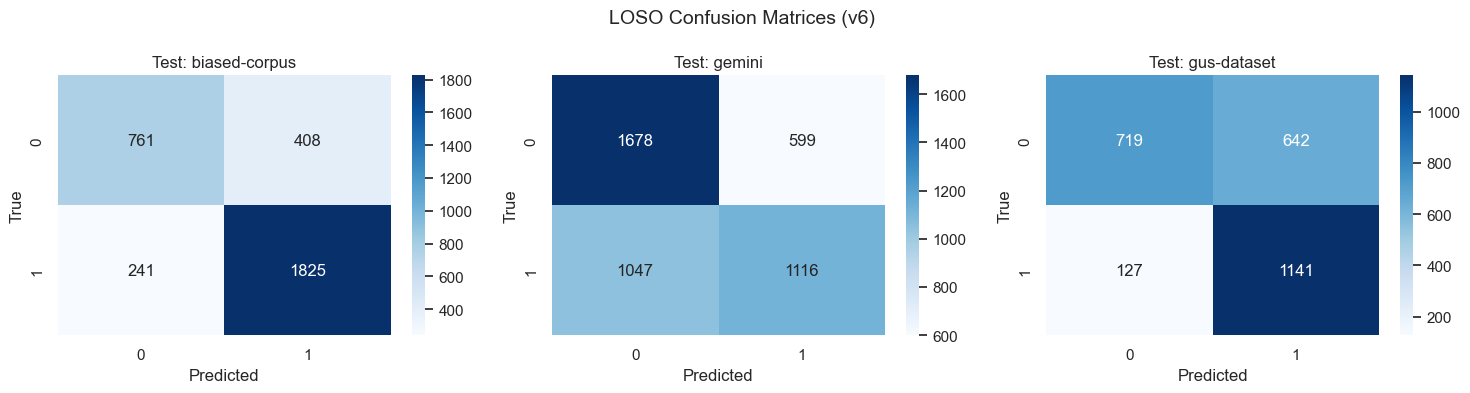

In [9]:
fig, axes = plt.subplots(1, len(df_loso), figsize=(5 * len(df_loso), 4))
if len(df_loso) == 1:
    axes = [axes]
for i, row in df_loso.iterrows():
    cm = np.array(row['confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Test: {row["test_source"]}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
plt.suptitle('LOSO Confusion Matrices (v6)', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Source Classifier: Predict Dataset Origin

Train a multiclass classifier to predict the source from the same BERT attention features.
If accuracy is much higher than the random baseline, the features encode source/domain information.

Source labels: ['biased-corpus', 'gemini', 'gus-dataset']
Source distribution: {0: 3235, 1: 4440, 2: 2629}
Random baseline: 33.3%

Train: 8232 | Test: 2072

Training source classifiers (3-way)...
  LogReg       CV Accuracy:   0.6845 (+/- 0.0070)
  LogReg       Test Accuracy: 0.6897
  XGBoost      CV Accuracy:   0.6823 (+/- 0.0054)
  XGBoost      Test Accuracy: 0.6805

Source Classifier (LogReg) - Test Accuracy: 0.6897
Random baseline: 0.3333 (3 classes)

Classification Report:
               precision    recall  f1-score   support

biased-corpus       0.54      0.64      0.59       605
       gemini       0.85      0.88      0.87       929
  gus-dataset       0.57      0.41      0.48       538

     accuracy                           0.69      2072
    macro avg       0.65      0.64      0.64      2072
 weighted avg       0.69      0.69      0.68      2072

Confusion Matrix:
               biased-corpus  gemini  gus-dataset
biased-corpus            387      78          140
gemini      

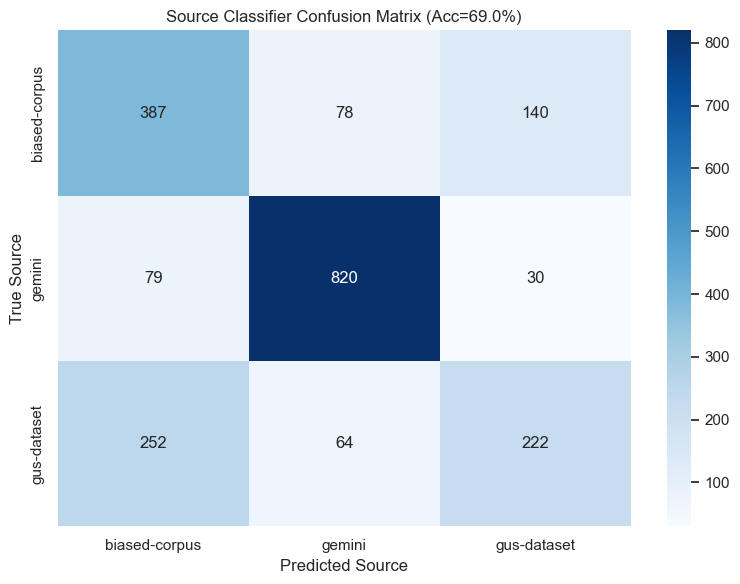

In [10]:
le = LabelEncoder()
y_source = le.fit_transform(sources)

print(f'Source labels: {list(le.classes_)}')
print(f'Source distribution: {dict(Counter(y_source))}')
print(f'Random baseline: {1 / len(le.classes_):.1%}')

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx_src, test_idx_src = next(gss.split(X_final, y_source, groups=groups))

X_train_src = X_final.iloc[train_idx_src]
X_test_src = X_final.iloc[test_idx_src]
y_train_src = y_source[train_idx_src]
y_test_src = y_source[test_idx_src]
groups_train_src = groups[train_idx_src]

print(f'\nTrain: {len(X_train_src)} | Test: {len(X_test_src)}')

src_models = {
    'LogReg': LogisticRegression(solver='lbfgs', max_iter=1000),
    'XGBoost': XGBClassifier(
        tree_method='approx',
        max_depth=8,
        n_estimators=500,
        learning_rate=0.05,
        eval_metric='mlogloss',
        random_state=RANDOM_STATE,
    ),
}

cv_src = StratifiedGroupKFold(n_splits=5)
best_src_pred = None
best_src_acc = -1
best_src_name = None

print(f'\nTraining source classifiers ({len(le.classes_)}-way)...')
for name, model in src_models.items():
    src_pipeline = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', model),
    ])

    cv_scores = cross_validate(
        src_pipeline,
        X_train_src,
        y_train_src,
        cv=cv_src,
        scoring='accuracy',
        groups=groups_train_src,
    )
    print(f'  {name:12} CV Accuracy:   {cv_scores["test_score"].mean():.4f} (+/- {cv_scores["test_score"].std():.4f})')

    src_pipeline.fit(X_train_src, y_train_src)
    y_pred_src = src_pipeline.predict(X_test_src)
    acc = accuracy_score(y_test_src, y_pred_src)
    print(f'  {name:12} Test Accuracy: {acc:.4f}')

    if acc > best_src_acc:
        best_src_acc = acc
        best_src_pred = y_pred_src
        best_src_name = name

print('\n' + '=' * 64)
print(f'Source Classifier ({best_src_name}) - Test Accuracy: {best_src_acc:.4f}')
print(f'Random baseline: {1 / len(le.classes_):.4f} ({len(le.classes_)} classes)')
print('=' * 64)
print('\nClassification Report:')
print(classification_report(y_test_src, best_src_pred, target_names=le.classes_, zero_division=0))

cm_src = confusion_matrix(y_test_src, best_src_pred)
print('Confusion Matrix:')
print(pd.DataFrame(cm_src, index=le.classes_, columns=le.classes_))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_src, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Source')
plt.ylabel('True Source')
plt.title(f'Source Classifier Confusion Matrix (Acc={best_src_acc:.1%})')
plt.tight_layout()
plt.show()

## 7. Bias Classifier on Original Features

Train/test the bias classifier with a **pair-aware** group split. Counterfactuals are used as training augmentation only — the test set contains only originals and unpaired entries (simulating real-world data). All members of a counterfactual pair stay in the same split to prevent leakage.

In [11]:
# === Pair-aware split: CFs in train only, test = originals + unpaired ===

# Step 1: Identify CF and non-CF entries by position
is_cf = (df_features['role'] == 'counterfactual').values
non_cf_positions = np.where(~is_cf)[0]
cf_positions = np.where(is_cf)[0]

print(f'Non-CF entries (originals + unpaired): {len(non_cf_positions)}')
print(f'Counterfactual entries: {len(cf_positions)}')

# Step 2: Build pair_id-based groups for non-CF entries
non_cf_pair_ids = df_features.iloc[non_cf_positions]['pair_id'].copy()
mask_no_pair = non_cf_pair_ids.isna()
non_cf_pair_ids[mask_no_pair] = ['unpaired_' + str(i) for i in range(mask_no_pair.sum())]
non_cf_groups = non_cf_pair_ids.values

X_non_cf = X_final.iloc[non_cf_positions]
y_non_cf = y.iloc[non_cf_positions]

# Step 3: GroupShuffleSplit on non-CF data only
gss_bias = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_noncf_local, test_noncf_local = next(gss_bias.split(X_non_cf, y_non_cf, groups=non_cf_groups))

# Convert local indices back to global positional indices
train_noncf_positions = non_cf_positions[train_noncf_local]
test_positions = non_cf_positions[test_noncf_local]

# Step 4: Add CFs to train — only those whose pair's original is in train
train_pair_ids = set(df_features.iloc[train_noncf_positions]['pair_id'].dropna())
cf_pair_ids = df_features.iloc[cf_positions]['pair_id']
cf_in_train_mask = cf_pair_ids.isin(train_pair_ids).values
cf_for_train_positions = cf_positions[cf_in_train_mask]
cf_excluded_positions = cf_positions[~cf_in_train_mask]

train_idx = np.concatenate([train_noncf_positions, cf_for_train_positions])
test_idx = test_positions

X_train = X_final.iloc[train_idx]
X_test = X_final.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# Groups for training set (needed for group-aware CV)
train_group_col = df_features.iloc[train_idx]['pair_id'].copy()
mask_no = train_group_col.isna()
train_group_col[mask_no] = ['unpaired_' + str(i) for i in range(mask_no.sum())]
groups_train = train_group_col.values

print(f'\n=== Split Summary ===')
print(f'Training Set: {X_train.shape[0]} samples')
print(f'  - Originals + unpaired: {len(train_noncf_positions)}')
print(f'  - Counterfactuals (augmentation): {len(cf_for_train_positions)}')
print(f'Testing Set:  {X_test.shape[0]} samples (originals + unpaired only)')
print(f'Excluded CFs (pair in test): {len(cf_excluded_positions)}')

# Leakage checks
train_texts = set(df_features.iloc[train_idx]['text'])
test_texts = set(df_features.iloc[test_idx]['text'])
overlap = train_texts & test_texts
print(f'\nLeakage Check:')
print(f'  Text overlap: {len(overlap)} (should be 0)')
assert len(overlap) == 0, 'LEAKAGE DETECTED: overlapping texts between train and test!'

train_pairs = set(df_features.iloc[train_idx]['pair_id'].dropna())
test_pairs = set(df_features.iloc[test_idx]['pair_id'].dropna())
pair_overlap = train_pairs & test_pairs
print(f'  Pair_id overlap: {len(pair_overlap)} (should be 0)')
assert len(pair_overlap) == 0, 'LEAKAGE DETECTED: pair_id shared between train and test!'

# Source distribution check
print(f'\nSource Distribution:')
train_sources_dist = pd.Series(sources[train_idx]).value_counts(normalize=True)
test_sources_dist = pd.Series(sources[test_idx]).value_counts(normalize=True)
source_df = pd.DataFrame({'train': train_sources_dist, 'test': test_sources_dist}).fillna(0)
source_df['diff'] = (source_df['train'] - source_df['test']).abs()
print(source_df.round(3).to_string())

# Label distribution check
print(f'\nLabel Distribution:')
print(f'  Train: biased={int(y_train.sum())}, neutral={int((y_train == 0).sum())} ({y_train.mean():.1%} biased)')
print(f'  Test:  biased={int(y_test.sum())}, neutral={int((y_test == 0).sum())} ({y_test.mean():.1%} biased)')

# --- Model Comparison ---
models = {
    'LogReg': LogisticRegression(solver='liblinear', max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        tree_method='approx',
        max_depth=8,
        n_estimators=500,
        learning_rate=0.05,
        min_child_weight=1,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(50,),
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        alpha=0.01,
        random_state=RANDOM_STATE,
    ),
}

results = {}
cv = StratifiedGroupKFold(n_splits=5)

print('\nComparing models (original features)')
for name, model in models.items():
    pipeline = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', model),
    ])
    scoring = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        groups=groups_train,
    )
    results[name] = {
        'auc': scores['test_roc_auc'].mean(),
        'accuracy': scores['test_accuracy'].mean(),
        'precision': scores['test_precision'].mean(),
        'recall': scores['test_recall'].mean(),
        'f1': scores['test_f1'].mean(),
    }
    print(
        f'{name:12} | '
        f'AUC: {results[name]["auc"]:.4f} | '
        f'Acc: {results[name]["accuracy"]:.4f} | '
        f'Prec: {results[name]["precision"]:.4f} | '
        f'Rec: {results[name]["recall"]:.4f} | '
        f'F1: {results[name]["f1"]:.4f}'
    )

best_model_name = max(results, key=lambda name: results[name]['auc'])
print(f'\nBest model: {best_model_name} (AUC={results[best_model_name]["auc"]:.4f})')

Non-CF entries (originals + unpaired): 6457
Counterfactual entries: 3847

=== Split Summary ===
Training Set: 7703 samples
  - Originals + unpaired: 4842
  - Counterfactuals (augmentation): 2861
Testing Set:  1615 samples (originals + unpaired only)
Excluded CFs (pair in test): 986

Leakage Check:
  Text overlap: 0 (should be 0)
  Pair_id overlap: 0 (should be 0)

Source Distribution:
               train   test   diff
gemini         0.425  0.370  0.055
biased-corpus  0.318  0.341  0.022
gus-dataset    0.256  0.289  0.033

Label Distribution:
  Train: biased=4102, neutral=3601 (53.3% biased)
  Test:  biased=766, neutral=849 (47.4% biased)

Comparing models (original features)
LogReg       | AUC: 0.9514 | Acc: 0.8790 | Prec: 0.8844 | Rec: 0.8891 | F1: 0.8867
RandomForest | AUC: 0.9019 | Acc: 0.8145 | Prec: 0.8113 | Rec: 0.8498 | F1: 0.8299
XGBoost      | AUC: 0.9391 | Acc: 0.8607 | Prec: 0.8525 | Rec: 0.8932 | F1: 0.8723
MLP          | AUC: 0.9490 | Acc: 0.8745 | Prec: 0.8735 | Rec: 0.8

In [12]:
param_grids = {
    'RandomForest': {
        'm__n_estimators': [50, 100, 200],
        'm__max_depth': [None, 10, 20],
        'm__min_samples_leaf': [1, 2, 4],
    },
    'XGBoost': {
        'm__n_estimators': [50, 100, 200],
        'm__learning_rate': [0.01, 0.1, 0.2],
        'm__max_depth': [3, 5, 7],
    },
    'MLP': {
        'm__hidden_layer_sizes': [(32,), (50,), (64,), (32, 16), (50, 25)],
        'm__alpha': [0.01, 0.05, 0.1, 0.2, 0.5],
        'm__learning_rate_init': [0.001, 0.005, 0.01],
        'm__activation': ['relu', 'tanh'],
        'm__solver': ['adam'],
        'm__early_stopping': [True],
        'm__validation_fraction': [0.15],
        'm__n_iter_no_change': [15],
    },
    'LogReg': {
        'm__C': [0.1, 1.0, 10.0],
    },
}

print(f'Tuning {best_model_name}...')
pipeline = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('s', StandardScaler()),
    ('m', models[best_model_name]),
])

search = HalvingRandomSearchCV(
    pipeline,
    param_distributions=param_grids[best_model_name],
    cv=StratifiedGroupKFold(n_splits=5),
    scoring='roc_auc',
    n_jobs=1,
    factor=1.5,
    resource='n_samples',
    random_state=RANDOM_STATE,
)
search.fit(X_train, y_train, groups=groups_train)

print(f'Best params: {search.best_params_}')
final_model = search.best_estimator_

Tuning LogReg...
Best params: {'m__C': 10.0}


Final Test Set Results (original features)
AUC:       0.9557
Accuracy:  0.8774
Precision: 0.8541
Recall:    0.8943
F1:        0.8737

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       849
           1       0.85      0.89      0.87       766

    accuracy                           0.88      1615
   macro avg       0.88      0.88      0.88      1615
weighted avg       0.88      0.88      0.88      1615



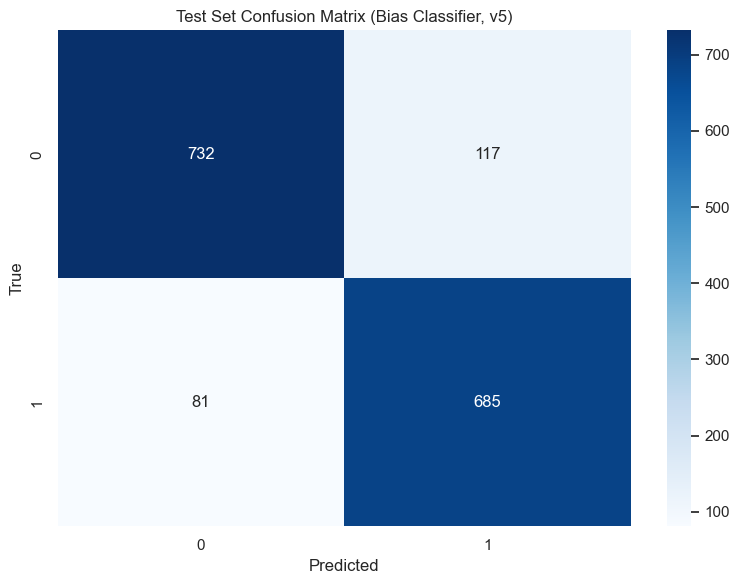

In [13]:
y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 1]

orig_auc = roc_auc_score(y_test, y_test_prob)
orig_acc = accuracy_score(y_test, y_test_pred)
orig_prec = precision_score(y_test, y_test_pred, zero_division=0)
orig_rec = recall_score(y_test, y_test_pred, zero_division=0)
orig_f1 = f1_score(y_test, y_test_pred, zero_division=0)

print('Final Test Set Results (original features)')
print(f'AUC:       {orig_auc:.4f}')
print(f'Accuracy:  {orig_acc:.4f}')
print(f'Precision: {orig_prec:.4f}')
print(f'Recall:    {orig_rec:.4f}')
print(f'F1:        {orig_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_test_pred, zero_division=0))

cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Test Set Confusion Matrix (Bias Classifier, v9)')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.show()

### 7.1 Counterfactual Consistency Evaluation

Measure whether the model correctly flips its prediction when moving from an original sentence to its counterfactual pair. A faithful bias detector should predict the original label correctly AND flip for the CF.

Counterfactual Consistency Analysis

Total counterfactual pairs evaluated: 3844
  Held-out pairs (original in test set): 983

--- ALL PAIRS (3844 pairs) ---
  Both predictions correct (full consistency): 80.2%
  Original correctly predicted:                 89.9%
  Counterfactual correctly predicted:           89.8%
  Probability direction correct:                97.7%
  Mean probability delta (|P(orig) - P(cf)|):  0.714

--- HELD-OUT PAIRS ONLY (983 pairs) ---
  Both predictions correct (full consistency): 78.2%
  Original correctly predicted:                 88.1%
  Counterfactual correctly predicted:           89.5%
  Probability direction correct:                97.3%
  Mean probability delta (|P(orig) - P(cf)|):  0.705

--- Consistency by Source ---
  gemini            : consistency=84.7%  direction=97.8%  n=2156
  gus-dataset       : consistency=74.3%  direction=96.9%  n=731
  biased-corpus     : consistency=74.5%  direction=98.1%  n=957

--- Top 10 Inconsistent Pairs (lowest pro

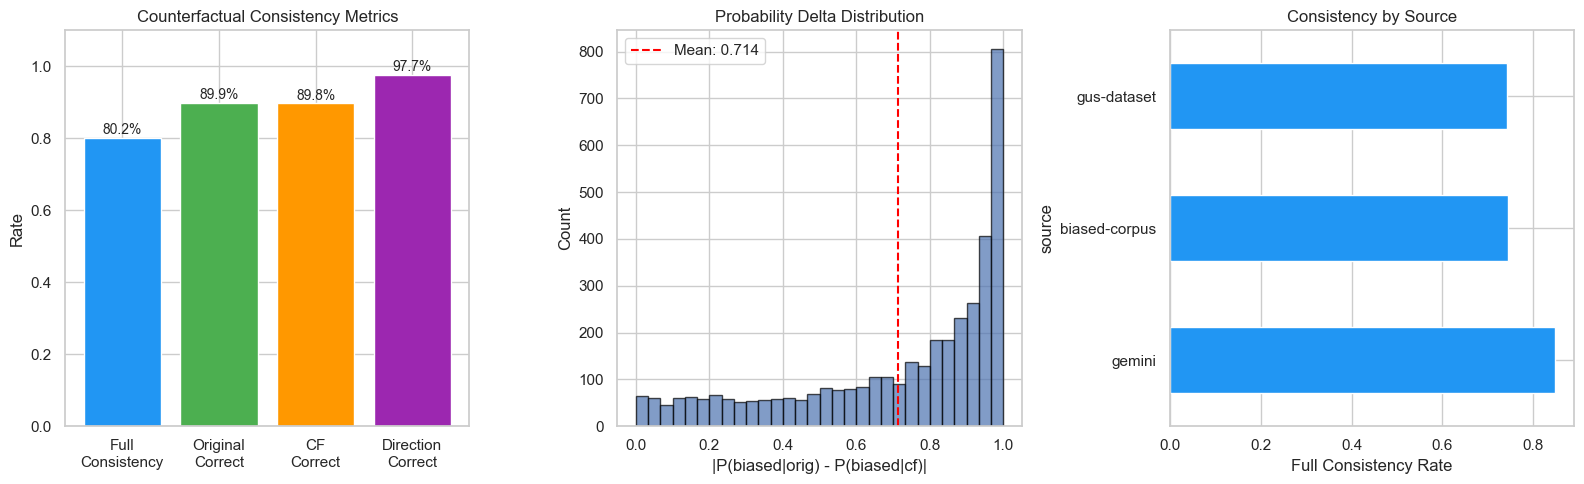

In [14]:
# === Counterfactual Consistency Evaluation ===
print('Counterfactual Consistency Analysis')
print('=' * 60)

paired_entries = df_features[df_features['pair_id'].notna()].copy()
pair_groups = paired_entries.groupby('pair_id')

test_idx_set = set(test_idx)
results_cc = []

for pid, group in pair_groups:
    orig = group[group['role'] == 'original']
    cf = group[group['role'] == 'counterfactual']
    if len(orig) != 1 or len(cf) != 1:
        continue

    orig_pos = orig.index[0]
    cf_pos = cf.index[0]

    X_orig = X_final.iloc[[orig_pos]]
    X_cf = X_final.iloc[[cf_pos]]

    pred_orig = final_model.predict(X_orig)[0]
    pred_cf = final_model.predict(X_cf)[0]
    prob_orig = final_model.predict_proba(X_orig)[0, 1]
    prob_cf = final_model.predict_proba(X_cf)[0, 1]

    label_orig = int(y.iloc[orig_pos])
    label_cf = int(y.iloc[cf_pos])

    orig_correct = (pred_orig == label_orig)
    cf_correct = (pred_cf == label_cf)
    both_correct = orig_correct and cf_correct

    if label_orig > label_cf:
        direction_correct = prob_orig > prob_cf
    elif label_orig < label_cf:
        direction_correct = prob_cf > prob_orig
    else:
        direction_correct = True

    prob_delta = abs(prob_orig - prob_cf)

    # Determine which positional index to check for held-out status
    # orig_pos is the DataFrame index; we need to check if it's in test_idx (positional)
    is_held_out = orig_pos in test_idx_set

    results_cc.append({
        'pair_id': pid,
        'text_orig': orig['text'].values[0][:80],
        'text_cf': cf['text'].values[0][:80],
        'label_orig': label_orig,
        'label_cf': label_cf,
        'pred_orig': pred_orig,
        'pred_cf': pred_cf,
        'prob_orig': prob_orig,
        'prob_cf': prob_cf,
        'prob_delta': prob_delta,
        'orig_correct': orig_correct,
        'cf_correct': cf_correct,
        'both_correct': both_correct,
        'direction_correct': direction_correct,
        'source': orig['source_canonical'].values[0],
        'is_held_out': is_held_out,
    })

df_cc = pd.DataFrame(results_cc)
df_cc_heldout = df_cc[df_cc['is_held_out']]

print(f'\nTotal counterfactual pairs evaluated: {len(df_cc)}')
print(f'  Held-out pairs (original in test set): {len(df_cc_heldout)}')

for label, subset in [('ALL PAIRS', df_cc), ('HELD-OUT PAIRS ONLY', df_cc_heldout)]:
    if len(subset) == 0:
        continue
    print(f'\n--- {label} ({len(subset)} pairs) ---')
    print(f'  Both predictions correct (full consistency): {subset["both_correct"].mean():.1%}')
    print(f'  Original correctly predicted:                 {subset["orig_correct"].mean():.1%}')
    print(f'  Counterfactual correctly predicted:           {subset["cf_correct"].mean():.1%}')
    print(f'  Probability direction correct:                {subset["direction_correct"].mean():.1%}')
    print(f'  Mean probability delta (|P(orig) - P(cf)|):  {subset["prob_delta"].mean():.3f}')

print(f'\n--- Consistency by Source ---')
for src in df_cc['source'].unique():
    sub = df_cc[df_cc['source'] == src]
    print(f'  {src:18s}: consistency={sub["both_correct"].mean():.1%}  direction={sub["direction_correct"].mean():.1%}  n={len(sub)}')

# Failure analysis
failures = df_cc[~df_cc['both_correct']].sort_values('prob_delta', ascending=True)
print(f'\n--- Top 10 Inconsistent Pairs (lowest probability delta) ---')
for _, row in failures.head(10).iterrows():
    print(f'  [{row["source"]}] orig={row["label_orig"]}->pred={row["pred_orig"]} (p={row["prob_orig"]:.2f})  |  '
          f'cf={row["label_cf"]}->pred={row["pred_cf"]} (p={row["prob_cf"]:.2f})  delta={row["prob_delta"]:.3f}')
    print(f'    ORIG: {row["text_orig"]}')
    print(f'    CF:   {row["text_cf"]}')

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['both_correct', 'orig_correct', 'cf_correct', 'direction_correct']
labels_m = ['Full\nConsistency', 'Original\nCorrect', 'CF\nCorrect', 'Direction\nCorrect']
vals = [df_cc[m].mean() for m in metrics]
bars = axes[0].bar(labels_m, vals, color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{v:.1%}',
                 ha='center', fontsize=10)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Rate')
axes[0].set_title('Counterfactual Consistency Metrics')

axes[1].hist(df_cc['prob_delta'], bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(df_cc['prob_delta'].mean(), color='red', linestyle='--',
                label=f'Mean: {df_cc["prob_delta"].mean():.3f}')
axes[1].set_xlabel('|P(biased|orig) - P(biased|cf)|')
axes[1].set_ylabel('Count')
axes[1].set_title('Probability Delta Distribution')
axes[1].legend()

src_consistency = df_cc.groupby('source')['both_correct'].mean().sort_values(ascending=False)
src_consistency.plot(kind='barh', ax=axes[2], color='#2196F3')
axes[2].set_xlabel('Full Consistency Rate')
axes[2].set_title('Consistency by Source')

plt.tight_layout()
plt.show()

In [15]:
test_texts_arr = df_features.iloc[test_idx]['text'].values
test_sources = df_features.iloc[test_idx]['source_canonical'].values

errors_mask = y_test.values != y_test_pred
false_positives = (y_test.values == 0) & (y_test_pred == 1)
false_negatives = (y_test.values == 1) & (y_test_pred == 0)

print(f'Total test: {len(y_test)}')
print(f'Total errors: {int(errors_mask.sum())} ({errors_mask.sum() / len(y_test) * 100:.2f}%)')
print(f'  False positives: {int(false_positives.sum())}')
print(f'  False negatives: {int(false_negatives.sum())}')

print('\nErrors by source:')
print(f'  {"Source":18} {"Errors":>6} / {"Total":>6}  {"Rate":>6}')
for source in unique_sources:
    source_mask = test_sources == source
    source_errors = errors_mask & source_mask
    source_total = int(source_mask.sum())
    source_rate = source_errors.sum() / source_total if source_total else 0
    print(f'  {source:18} {int(source_errors.sum()):6d} / {source_total:6d}  {source_rate * 100:5.1f}%')

error_df = pd.DataFrame({
    'text': test_texts_arr[errors_mask],
    'true_label': y_test.values[errors_mask],
    'pred_label': y_test_pred[errors_mask],
    'source': test_sources[errors_mask],
})


def classify_text_type(text: str) -> str:
    text_lower = text.lower().strip()
    if text_lower.endswith('?') or text_lower.startswith(('what', 'why', 'how', 'when', 'where', 'who', 'can', 'is', 'are', 'do', 'does')):
        return 'question'
    if any(kw in text_lower for kw in ['study', 'research', 'data', 'evidence', 'analysis', 'experiment', 'theory', 'hypothesis']):
        return 'technical_scientific'
    if any(text_lower.startswith(prefix) for prefix in ['that person', 'they', 'someone', 'a person']):
        return 'neutral_descriptive'
    return 'statement'


error_df['text_type'] = error_df['text'].apply(classify_text_type)
error_df['error_type'] = error_df['true_label'].map({0: 'FP (neutral->biased)', 1: 'FN (biased->neutral)'})

print('\nErrors by text type:')
print(pd.crosstab(error_df['text_type'], error_df['error_type'], margins=True))

fp_df = error_df[error_df['true_label'] == 0]
fn_df = error_df[error_df['true_label'] == 1]
print('\nSample errors:')
print(f'  False positives: {len(fp_df)} total')
for _, row in fp_df.sample(n=min(5, len(fp_df)), random_state=RANDOM_STATE).iterrows():
    print(f'    [{row["source"]}] ({row["text_type"]}) {row["text"]}')

print(f'\n  False negatives: {len(fn_df)} total')
for _, row in fn_df.sample(n=min(5, len(fn_df)), random_state=RANDOM_STATE).iterrows():
    print(f'    [{row["source"]}] ({row["text_type"]}) {row["text"]}')

error_path = notebook_dir / 'error_analysis_source_diagnosis_v5.csv'
error_df.to_csv(error_path, index=False)
print(f'\nSaved full error analysis to: {error_path}')

Total test: 1615
Total errors: 198 (12.26%)
  False positives: 117
  False negatives: 81

Errors by source:
  Source             Errors /  Total    Rate
  biased-corpus          81 /    550   14.7%
  gemini                 48 /    598    8.0%
  gus-dataset            69 /    467   14.8%

Errors by text type:
error_type            FN (biased->neutral)  FP (neutral->biased)  All
text_type                                                            
neutral_descriptive                      1                     3    4
question                                30                    19   49
statement                               50                    89  139
technical_scientific                     0                     6    6
All                                     81                   117  198

Sample errors:
  False positives: 117 total
    [gemini] (statement) Queer individuals are as emotionally stable and capable as any other group in high-pressure environments.
    [biased-corpus] (sta

## 8. Residualization: Remove Source Signal from Features

For each feature, regress it against one-hot encoded source labels and keep the residuals.
If the source classifier collapses on residualized features, source information has been removed.
If the bias classifier still performs well, it suggests the model retains genuine bias signal.

In [16]:
source_dummies = pd.get_dummies(df_features['source_canonical'], drop_first=False).values
print(f'Source dummies shape: {source_dummies.shape}')
print(f'Original features shape: {X_final.shape}')

X_residual = X_final.copy()
lr = LinearRegression()

for col in X_final.columns:
    feature_values = X_final[col].values.reshape(-1, 1)
    lr.fit(source_dummies, feature_values)
    predicted_by_source = lr.predict(source_dummies)
    X_residual[col] = feature_values.ravel() - predicted_by_source.ravel()

print(f'\nResidualized features shape: {X_residual.shape}')

y_source_check = LabelEncoder().fit_transform(sources)
source_check_pipe = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('s', StandardScaler()),
    ('m', LogisticRegression(solver='lbfgs', max_iter=1000)),
])

tr_idx, te_idx = next(GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE).split(X_residual, y_source_check, groups=groups))
source_check_pipe.fit(X_residual.iloc[tr_idx], y_source_check[tr_idx])
src_acc_residual = accuracy_score(y_source_check[te_idx], source_check_pipe.predict(X_residual.iloc[te_idx]))

print('\nSource classifier accuracy:')
print(f'  Before residualization: {best_src_acc:.4f}')
print(f'  After residualization:  {src_acc_residual:.4f}')
print(f'  Random baseline:        {1 / len(unique_sources):.4f}')

Source dummies shape: (10304, 3)
Original features shape: (10304, 3238)

Residualized features shape: (10304, 3238)

Source classifier accuracy:
  Before residualization: 0.6897
  After residualization:  0.3848
  Random baseline:        0.3333


### 8.1 LOSO on Residualized Features

In [17]:
print('LOSO on residualized features')
print('=' * 72 + '\n')

loso_resid_results = []

for test_source in unique_sources:
    print(f'--- Test on [{test_source}] ---')

    test_mask = sources == test_source
    train_mask = ~test_mask

    X_train_r = X_residual.iloc[np.where(train_mask)[0]]
    X_test_r = X_residual.iloc[np.where(test_mask)[0]]
    y_train_r = y.iloc[np.where(train_mask)[0]]
    y_test_r = y.iloc[np.where(test_mask)[0]]

    print(f'  Train: {len(X_train_r)} | Test: {len(X_test_r)}')
    print(f'  Test labels: biased={int(y_test_r.sum())}, neutral={int((y_test_r == 0).sum())}')

    pipeline_r = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', XGBClassifier(
            tree_method='approx',
            max_depth=8,
            n_estimators=500,
            learning_rate=0.05,
            min_child_weight=1,
            gamma=0.1,
            reg_alpha=0.1,
            reg_lambda=1.0,
            eval_metric='logloss',
            random_state=RANDOM_STATE,
        )),
    ])

    pipeline_r.fit(X_train_r, y_train_r)
    y_pred_r = pipeline_r.predict(X_test_r)
    y_prob_r = pipeline_r.predict_proba(X_test_r)[:, 1]

    acc = accuracy_score(y_test_r, y_pred_r)
    prec = precision_score(y_test_r, y_pred_r, zero_division=0)
    rec = recall_score(y_test_r, y_pred_r, zero_division=0)
    f1 = f1_score(y_test_r, y_pred_r, zero_division=0)
    auc = roc_auc_score(y_test_r, y_prob_r)
    cm = confusion_matrix(y_test_r, y_pred_r)

    print(f'  Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUC={auc:.4f}')
    print(f'  CM: {cm.tolist()}\n')

    loso_resid_results.append({
        'test_source': test_source,
        'n_test': len(X_test_r),
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'auc': auc,
        'confusion_matrix': cm.tolist(),
    })

df_loso_resid = pd.DataFrame(loso_resid_results)

LOSO on residualized features

--- Test on [biased-corpus] ---
  Train: 7069 | Test: 3235
  Test labels: biased=2066, neutral=1169
  Acc=0.7926 | Prec=0.8736 | Rec=0.7894 | F1=0.8294 | AUC=0.8828
  CM: [[933, 236], [435, 1631]]

--- Test on [gemini] ---
  Train: 5864 | Test: 4440
  Test labels: biased=2163, neutral=2277
  Acc=0.8043 | Prec=0.7946 | Rec=0.8067 | F1=0.8006 | AUC=0.8751
  CM: [[1826, 451], [418, 1745]]

--- Test on [gus-dataset] ---
  Train: 7675 | Test: 2629
  Test labels: biased=1268, neutral=1361
  Acc=0.7535 | Prec=0.6867 | Rec=0.8991 | F1=0.7787 | AUC=0.8302
  CM: [[841, 520], [128, 1140]]



COMPARISON: Original vs Residualized LOSO (v9)
  test_source  accuracy_original  f1_original  auc_original  accuracy_residual  f1_residual  auc_residual
biased-corpus           0.799382     0.849035      0.876035           0.792581     0.829392      0.882843
       gemini           0.629279     0.575554      0.678041           0.804279     0.800642      0.875082
  gus-dataset           0.707493     0.747951      0.824172           0.753518     0.778689      0.830219


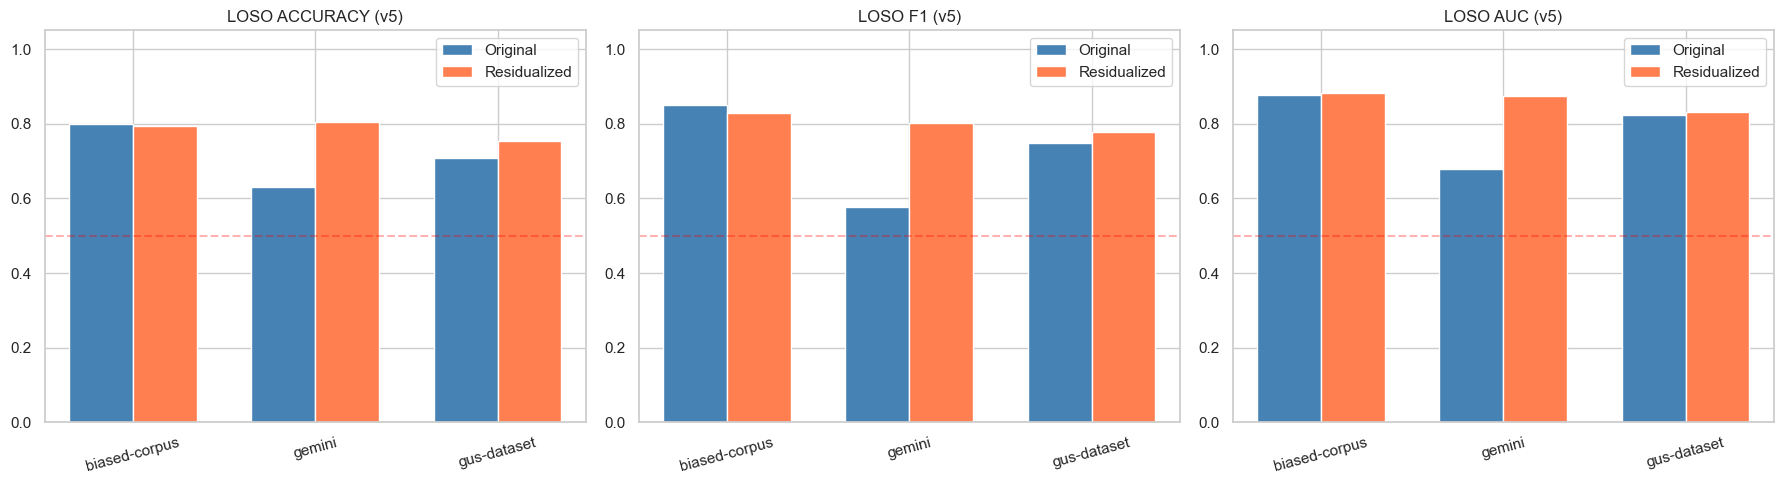

In [18]:
print('=' * 72)
print('COMPARISON: Original vs Residualized LOSO (v9)')
print('=' * 72)

comparison = df_loso[['test_source', 'accuracy', 'f1', 'auc']].merge(
    df_loso_resid[['test_source', 'accuracy', 'f1', 'auc']],
    on='test_source',
    suffixes=('_original', '_residual'),
)
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, metric in enumerate(['accuracy', 'f1', 'auc']):
    orig_col = f'{metric}_original'
    resid_col = f'{metric}_residual'
    x = np.arange(len(comparison))
    width = 0.35
    axes[i].bar(x - width / 2, comparison[orig_col], width, label='Original', color='steelblue')
    axes[i].bar(x + width / 2, comparison[resid_col], width, label='Residualized', color='coral')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(comparison['test_source'], rotation=15)
    axes[i].set_title(f'LOSO {metric.upper()} (v9)')
    axes[i].set_ylim(0, 1.05)
    axes[i].axhline(y=0.5, color='red', linestyle='--', alpha=0.3)
    axes[i].legend()
plt.tight_layout()
plt.show()

## 9. Bias Classifier on Residualized Features

Repeat the bias-classification workflow after removing source signal.

In [19]:
X_train_res = X_residual.iloc[train_idx]
X_test_res = X_residual.iloc[test_idx]

models_res = {
    'LogReg': LogisticRegression(solver='liblinear', max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        tree_method='approx',
        max_depth=8,
        n_estimators=500,
        learning_rate=0.05,
        min_child_weight=1,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(50,),
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        alpha=0.01,
        random_state=RANDOM_STATE,
    ),
}

results_res = {}
cv_res = StratifiedGroupKFold(n_splits=5)

print(f'Train: {len(X_train_res)} | Test: {len(X_test_res)}')
print(f'Label distribution (train): biased={int(y_train.sum())}, neutral={int((y_train == 0).sum())}')
print(f'Label distribution (test):  biased={int(y_test.sum())}, neutral={int((y_test == 0).sum())}')
print('\nComparing models on residualized features')

for name, model in models_res.items():
    pipeline_res = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', model),
    ])
    scores = cross_validate(
        pipeline_res,
        X_train_res,
        y_train,
        cv=cv_res,
        scoring=['roc_auc', 'accuracy', 'precision', 'recall', 'f1'],
        groups=groups_train,
    )
    results_res[name] = {
        'auc': scores['test_roc_auc'].mean(),
        'accuracy': scores['test_accuracy'].mean(),
        'precision': scores['test_precision'].mean(),
        'recall': scores['test_recall'].mean(),
        'f1': scores['test_f1'].mean(),
    }
    print(
        f'{name:12} | '
        f'AUC: {results_res[name]["auc"]:.4f} | '
        f'Acc: {results_res[name]["accuracy"]:.4f} | '
        f'Prec: {results_res[name]["precision"]:.4f} | '
        f'Rec: {results_res[name]["recall"]:.4f} | '
        f'F1: {results_res[name]["f1"]:.4f}'
    )

best_res_name = max(results_res, key=lambda name: results_res[name]['auc'])
print(f'\nBest residualized model: {best_res_name} (AUC={results_res[best_res_name]["auc"]:.4f})')

Train: 7703 | Test: 1615
Label distribution (train): biased=4102, neutral=3601
Label distribution (test):  biased=766, neutral=849

Comparing models on residualized features
LogReg       | AUC: 0.9443 | Acc: 0.8707 | Prec: 0.8781 | Rec: 0.8796 | F1: 0.8787
RandomForest | AUC: 0.9148 | Acc: 0.8310 | Prec: 0.8246 | Rec: 0.8671 | F1: 0.8453
XGBoost      | AUC: 0.9447 | Acc: 0.8700 | Prec: 0.8619 | Rec: 0.9003 | F1: 0.8807
MLP          | AUC: 0.9493 | Acc: 0.8778 | Prec: 0.8810 | Rec: 0.8910 | F1: 0.8859

Best residualized model: MLP (AUC=0.9493)


Tuning MLP on residualized features...
Best params: {'m__validation_fraction': 0.15, 'm__solver': 'adam', 'm__n_iter_no_change': 15, 'm__learning_rate_init': 0.005, 'm__hidden_layer_sizes': (32,), 'm__early_stopping': True, 'm__alpha': 0.2, 'm__activation': 'tanh'}

Final Test: Residualized Features (v9)
AUC:       0.9504
Accuracy:  0.8718
Precision: 0.8498
Recall:    0.8864
F1:        0.8677

Classification Report (Residualized):
              precision    recall  f1-score   support

           0       0.89      0.86      0.88       849
           1       0.85      0.89      0.87       766

    accuracy                           0.87      1615
   macro avg       0.87      0.87      0.87      1615
weighted avg       0.87      0.87      0.87      1615



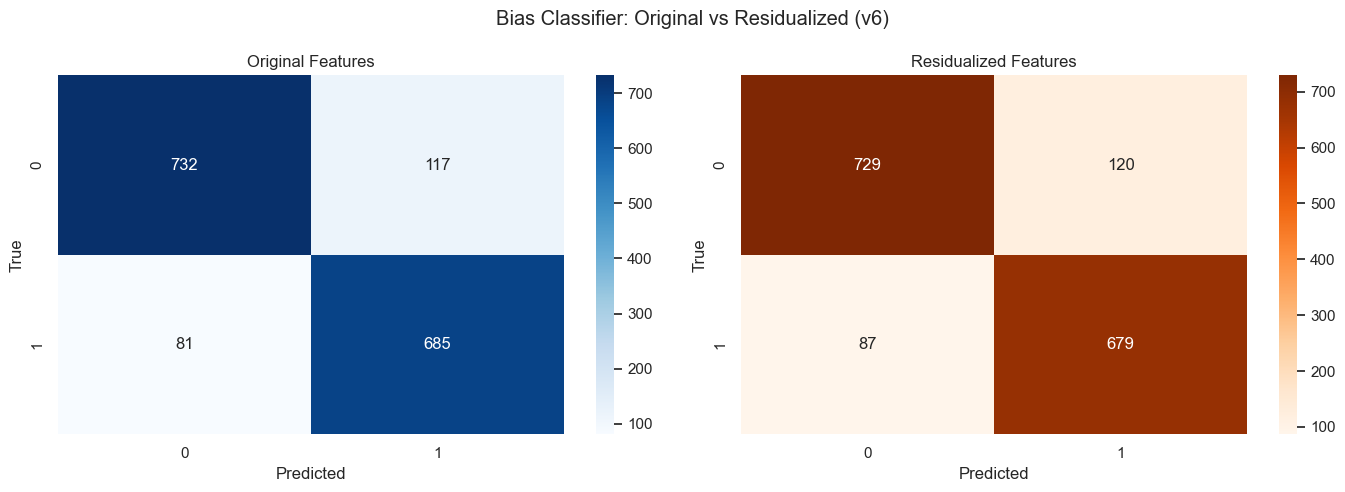


COMPARISON: Original vs Residualized (Test Set)
Metric       |   Original | Residualized |    Delta
----------------------------------------------------
AUC          |     0.9557 |       0.9504 |  -0.0053
Accuracy     |     0.8774 |       0.8718 |  -0.0056
F1           |     0.8737 |       0.8677 |  -0.0060
Precision    |     0.8541 |       0.8498 |  -0.0043
Recall       |     0.8943 |       0.8864 |  -0.0078


In [20]:
print(f'Tuning {best_res_name} on residualized features...')
pipeline_res = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('s', StandardScaler()),
    ('m', models_res[best_res_name]),
])

search_res = HalvingRandomSearchCV(
    pipeline_res,
    param_distributions=param_grids[best_res_name],
    cv=StratifiedGroupKFold(n_splits=5),
    scoring='roc_auc',
    n_jobs=1,
    factor=1.5,
    resource='n_samples',
    random_state=RANDOM_STATE,
)
search_res.fit(X_train_res, y_train, groups=groups_train)

print(f'Best params: {search_res.best_params_}')
final_model_res = search_res.best_estimator_

y_test_pred_res = final_model_res.predict(X_test_res)
y_test_prob_res = final_model_res.predict_proba(X_test_res)[:, 1]

auc_res = roc_auc_score(y_test, y_test_prob_res)
acc_res = accuracy_score(y_test, y_test_pred_res)
prec_res = precision_score(y_test, y_test_pred_res, zero_division=0)
rec_res = recall_score(y_test, y_test_pred_res, zero_division=0)
f1_res = f1_score(y_test, y_test_pred_res, zero_division=0)

print('\n' + '=' * 60)
print('Final Test: Residualized Features (v9)')
print('=' * 60)
print(f'AUC:       {auc_res:.4f}')
print(f'Accuracy:  {acc_res:.4f}')
print(f'Precision: {prec_res:.4f}')
print(f'Recall:    {rec_res:.4f}')
print(f'F1:        {f1_res:.4f}')
print('\nClassification Report (Residualized):')
print(classification_report(y_test, y_test_pred_res, zero_division=0))

cm_orig = confusion_matrix(y_test, y_test_pred)
cm_res = confusion_matrix(y_test, y_test_pred_res)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Original Features')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')

sns.heatmap(cm_res, annot=True, fmt='d', cmap='Oranges', ax=ax2)
ax2.set_title('Residualized Features')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')

plt.suptitle('Bias Classifier: Original vs Residualized (v6)')
plt.tight_layout()
plt.show()

print('\n' + '=' * 60)
print('COMPARISON: Original vs Residualized (Test Set)')
print('=' * 60)
print(f'{"Metric":12} | {"Original":>10} | {"Residualized":>12} | {"Delta":>8}')
print('-' * 52)
print(f'{"AUC":12} | {orig_auc:10.4f} | {auc_res:12.4f} | {auc_res - orig_auc:+8.4f}')
print(f'{"Accuracy":12} | {orig_acc:10.4f} | {acc_res:12.4f} | {acc_res - orig_acc:+8.4f}')
print(f'{"F1":12} | {orig_f1:10.4f} | {f1_res:12.4f} | {f1_res - orig_f1:+8.4f}')
print(f'{"Precision":12} | {orig_prec:10.4f} | {prec_res:12.4f} | {prec_res - orig_prec:+8.4f}')
print(f'{"Recall":12} | {orig_rec:10.4f} | {rec_res:12.4f} | {rec_res - orig_rec:+8.4f}')

ERROR ANALYSIS BY SOURCE: Original vs Residualized (v9)

Source             |  Orig Errors |  Resid Errors |  Orig Rate |  Resid Rate
------------------------------------------------------------------------------
biased-corpus      |    81 / 550   |    83 / 550   |     14.7% |      15.1%
gemini             |    48 / 598   |    44 / 598   |      8.0% |       7.4%
gus-dataset        |    69 / 467   |    80 / 467   |     14.8% |      17.1%
------------------------------------------------------------------------------
TOTAL              |   198 / 1615  |   207 / 1615  |     12.3% |      12.8%


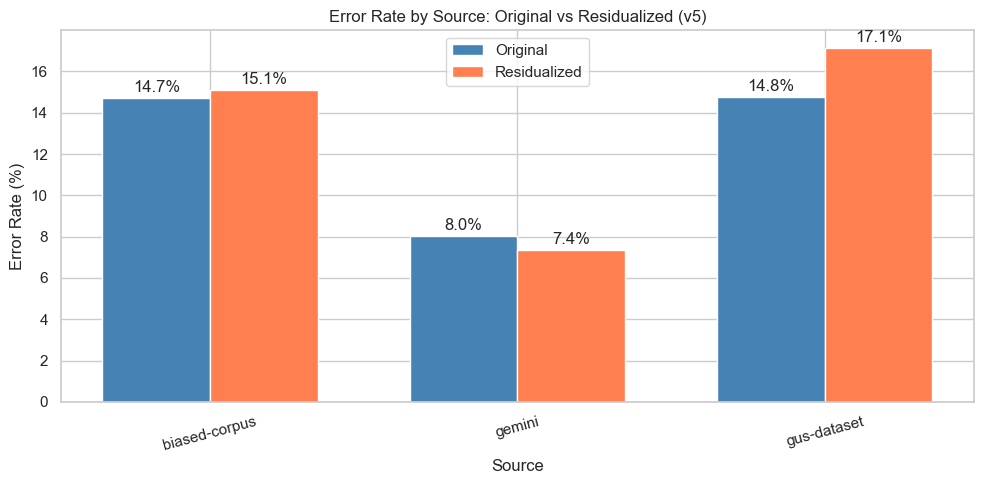

In [21]:
test_sources_arr = df_features.iloc[test_idx]['source_canonical'].values
errors_orig = y_test.values != y_test_pred
errors_resid = y_test.values != y_test_pred_res

print('=' * 72)
print('ERROR ANALYSIS BY SOURCE: Original vs Residualized (v9)')
print('=' * 72)
print(f'\n{"Source":18} | {"Orig Errors":>12} | {"Resid Errors":>13} | {"Orig Rate":>10} | {"Resid Rate":>11}')
print('-' * 78)

orig_rates = []
resid_rates = []
for src in unique_sources:
    src_mask = test_sources_arr == src
    src_total = int(src_mask.sum())
    orig_errs = int((errors_orig & src_mask).sum())
    resid_errs = int((errors_resid & src_mask).sum())
    orig_rate = orig_errs / src_total if src_total else 0
    resid_rate = resid_errs / src_total if src_total else 0
    orig_rates.append(orig_rate)
    resid_rates.append(resid_rate)
    print(f'{src:18} | {orig_errs:5d} / {src_total:<5d} | {resid_errs:5d} / {src_total:<5d} | {orig_rate:9.1%} | {resid_rate:10.1%}')

print('-' * 78)
print(f'{"TOTAL":18} | {int(errors_orig.sum()):5d} / {len(y_test):<5d} | {int(errors_resid.sum()):5d} / {len(y_test):<5d} | {errors_orig.mean():9.1%} | {errors_resid.mean():10.1%}')

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(unique_sources))
width = 0.35
bars1 = ax.bar(x - width / 2, [r * 100 for r in orig_rates], width, label='Original', color='steelblue')
bars2 = ax.bar(x + width / 2, [r * 100 for r in resid_rates], width, label='Residualized', color='coral')
ax.set_xlabel('Source')
ax.set_ylabel('Error Rate (%)')
ax.set_title('Error Rate by Source: Original vs Residualized (v9)')
ax.set_xticks(x)
ax.set_xticklabels(unique_sources, rotation=15)
ax.legend()
ax.bar_label(bars1, fmt='%.1f%%', padding=2)
ax.bar_label(bars2, fmt='%.1f%%', padding=2)
plt.tight_layout()
plt.show()

## 10. Conclusions and Interpretation

In [22]:
source_summary = df_features.groupby('source_canonical')['label'].agg(total='size', biased='sum').copy()
source_summary['neutral'] = source_summary['total'] - source_summary['biased']
source_summary['biased_rate'] = source_summary['biased'] / source_summary['total']

mean_loso_auc = df_loso['auc'].mean()
mean_loso_f1 = df_loso['f1'].mean()
mean_loso_resid_auc = df_loso_resid['auc'].mean()
mean_loso_resid_f1 = df_loso_resid['f1'].mean()

delta_auc = auc_res - orig_auc
delta_f1 = f1_res - orig_f1
source_rate_gap = source_summary['biased_rate'].max() - source_summary['biased_rate'].min()

print('=' * 72)
print('DIAGNOSTIC SUMMARY (v9)')
print('=' * 72)

print('\n1. DATASET STRUCTURE')
print(f'   - Entries: {len(df_features)}')
print(f'   - Unique texts: {df_features["text"].nunique()}')
print(f'   - Sources: {len(unique_sources)}')
for src, row in source_summary.iterrows():
    print(
        f'   - {src:18} total={int(row["total"]):4d} '
        f'biased={int(row["biased"]):4d} neutral={int(row["neutral"]):4d} '
        f'biased_rate={row["biased_rate"]:.1%}'
    )
if source_rate_gap > 0.5:
    print('   - Source and label are strongly imbalanced across sources.')
elif source_rate_gap > 0.2:
    print('   - Source and label are partially confounded across sources.')
else:
    print('   - Source and label are relatively balanced across sources.')

print('\n2. SOURCE CLASSIFIER')
print(f'   - Best source-classification accuracy: {best_src_acc:.1%}')
print(f'   - Random baseline: {1 / len(unique_sources):.1%}')
print(f'   - Residualized source accuracy: {src_acc_residual:.1%}')

print('\n3. LOSO GENERALIZATION')
print(f'   - Mean LOSO AUC (original):      {mean_loso_auc:.4f}')
print(f'   - Mean LOSO F1  (original):      {mean_loso_f1:.4f}')
print(f'   - Mean LOSO AUC (residualized):  {mean_loso_resid_auc:.4f}')
print(f'   - Mean LOSO F1  (residualized):  {mean_loso_resid_f1:.4f}')

print('\n4. BIAS CLASSIFIER TEST PERFORMANCE')
print(f'   - Original features:      AUC={orig_auc:.4f}, F1={orig_f1:.4f}, Acc={orig_acc:.4f}')
print(f'   - Residualized features:  AUC={auc_res:.4f}, F1={f1_res:.4f}, Acc={acc_res:.4f}')
print(f'   - Delta after residualization: AUC={delta_auc:+.4f}, F1={delta_f1:+.4f}')

if delta_auc < -0.05 or delta_f1 < -0.05:
    interpretation = 'Performance drops after source removal: the model was relying substantially on source artifacts.'
elif delta_auc > 0.05 or delta_f1 > 0.05:
    interpretation = 'Performance improves after source removal: source information was acting as noise, and the model keeps strong bias signal.'
else:
    interpretation = 'Performance is broadly stable after source removal: the model retains bias signal beyond source artifacts.'

print('\n5. INTERPRETATION')
print(f'   - {interpretation}')
print('   - Compare LOSO with random-baseline source prediction to assess how much domain shift still matters.')
print('   - Compare per-source error rates to see which source remains hardest after residualization.')
print('   - The v9 dataset uses bias_sentences_v9.json with 10,304 entries across 3 sources.')

DIAGNOSTIC SUMMARY (v9)

1. DATASET STRUCTURE
   - Entries: 10304
   - Unique texts: 10304
   - Sources: 3
   - biased-corpus      total=3235 biased=2066 neutral=1169 biased_rate=63.9%
   - gemini             total=4440 biased=2163 neutral=2277 biased_rate=48.7%
   - gus-dataset        total=2629 biased=1268 neutral=1361 biased_rate=48.2%
   - Source and label are relatively balanced across sources.

2. SOURCE CLASSIFIER
   - Best source-classification accuracy: 69.0%
   - Random baseline: 33.3%
   - Residualized source accuracy: 38.5%

3. LOSO GENERALIZATION
   - Mean LOSO AUC (original):      0.7927
   - Mean LOSO F1  (original):      0.7242
   - Mean LOSO AUC (residualized):  0.8627
   - Mean LOSO F1  (residualized):  0.8029

4. BIAS CLASSIFIER TEST PERFORMANCE
   - Original features:      AUC=0.9557, F1=0.8737, Acc=0.8774
   - Residualized features:  AUC=0.9504, F1=0.8677, Acc=0.8718
   - Delta after residualization: AUC=-0.0053, F1=-0.0060

5. INTERPRETATION
   - Performance is br

In [23]:
%cd ../..
from attention.models import ModelManager
from attention.bias.feature_extraction_notebooks import extract_features_for_sentence

c:\Users\anoca\Documents\GitHub\attention-atlas


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\anoca\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [24]:
# ─── Novel contrastive sentence pairs ───
# Each group: same TOPIC, same BIAS label, different FORM
# The model should give the same prediction within each group if it learned bias, not form.
from attention.models import ModelManager
from attention.bias.feature_extraction_notebooks import extract_features_for_sentence

probe_sentences = [
    # ═══ QUESTION vs STATEMENT — BIASED ═══
    {"text": "Why are women so bad at making rational decisions under pressure?",
     "expected": 1, "form": "question",    "contrast": "Q vs S", "topic": "gender rationality"},
    {"text": "Women are incapable of making rational decisions under pressure.",
     "expected": 1, "form": "statement",   "contrast": "Q vs S", "topic": "gender rationality"},

    {"text": "Don't you think immigrants are ruining the job market for locals?",
     "expected": 1, "form": "question",    "contrast": "Q vs S", "topic": "immigration jobs"},
    {"text": "Immigrants are ruining the job market for locals.",
     "expected": 1, "form": "statement",   "contrast": "Q vs S", "topic": "immigration jobs"},

    # ═══ QUESTION vs STATEMENT — NEUTRAL ═══
    {"text": "How many languages are spoken across the African continent?",
     "expected": 0, "form": "question",    "contrast": "Q vs S", "topic": "African languages"},
    {"text": "Over two thousand languages are spoken across the African continent.",
     "expected": 0, "form": "statement",   "contrast": "Q vs S", "topic": "African languages"},

    {"text": "What percentage of the global population lives in urban areas?",
     "expected": 0, "form": "question",    "contrast": "Q vs S", "topic": "urbanization"},
    {"text": "About 56 percent of the global population lives in urban areas.",
     "expected": 0, "form": "statement",   "contrast": "Q vs S", "topic": "urbanization"},

    # ═══ SCIENTIFIC vs CONVERSATIONAL — BIASED ═══
    {"text": "Empirical evidence consistently demonstrates that elderly individuals exhibit diminished cognitive processing speed.",
     "expected": 1, "form": "scientific",  "contrast": "Sci vs Conv", "topic": "age cognition"},
    {"text": "Old people are slow thinkers, everyone knows that.",
     "expected": 1, "form": "conversational", "contrast": "Sci vs Conv", "topic": "age cognition"},

    {"text": "Cross-cultural analyses indicate that populations from developing nations display lower intellectual aptitude.",
     "expected": 1, "form": "scientific",  "contrast": "Sci vs Conv", "topic": "nationality intelligence"},
    {"text": "People from poor countries are just not as smart as us.",
     "expected": 1, "form": "conversational", "contrast": "Sci vs Conv", "topic": "nationality intelligence"},

    # ═══ SCIENTIFIC vs CONVERSATIONAL — NEUTRAL ═══
    {"text": "Systematic reviews of randomized trials confirm that aerobic exercise reduces resting blood pressure.",
     "expected": 0, "form": "scientific",  "contrast": "Sci vs Conv", "topic": "exercise health"},
    {"text": "Going for a run a few times a week helps keep your blood pressure down.",
     "expected": 0, "form": "conversational", "contrast": "Sci vs Conv", "topic": "exercise health"},

    {"text": "Longitudinal meteorological data show an upward trend in average surface temperatures globally.",
     "expected": 0, "form": "scientific",  "contrast": "Sci vs Conv", "topic": "temperature trend"},
    {"text": "It seems like summers keep getting hotter every year around the world.",
     "expected": 0, "form": "conversational", "contrast": "Sci vs Conv", "topic": "temperature trend"},
]

print(f"Probe sentences: {len(probe_sentences)}")
print(f"  Biased: {sum(1 for s in probe_sentences if s['expected']==1)}")
print(f"  Neutral: {sum(1 for s in probe_sentences if s['expected']==0)}")

# ─── Extract features ───
print("\nLoading BERT model...")
manager = ModelManager()

print("Extracting features...")
probe_features = []
for i, item in enumerate(probe_sentences):
    feats = extract_features_for_sentence(item["text"], "bert-base-uncased", manager)
    probe_features.append(feats)
    print(f"  [{i+1:2d}/{len(probe_sentences)}] done")

df_probe = pd.DataFrame(probe_features)

# Align columns
missing = set(X_final.columns) - set(df_probe.columns)
extra = set(df_probe.columns) - set(X_final.columns)
for c in missing:
    df_probe[c] = 0.0
if extra:
    df_probe = df_probe.drop(columns=list(extra))
df_probe = df_probe[X_final.columns]
print(f"Features aligned: {df_probe.shape}")

# ─── Predict ───
pred = final_model.predict(df_probe)
prob = final_model.predict_proba(df_probe)[:, 1]

# ─── Display results by contrast group ───
from itertools import groupby

print(f"\n{'='*110}")
print("CONTRASTIVE PROBE RESULTS")
print(f"{'='*110}")

for contrast_name in ["Q vs S", "Sci vs Conv"]:
    group = [s for s in probe_sentences if s["contrast"] == contrast_name]
    group_idx = [i for i, s in enumerate(probe_sentences) if s["contrast"] == contrast_name]

    label_map = {1: "biased", 0: "neutral"}
    contrast_full = "QUESTION vs STATEMENT" if contrast_name == "Q vs S" else "SCIENTIFIC vs CONVERSATIONAL"
    print(f"\n{'─'*110}")
    print(f"  {contrast_full}")
    print(f"{'─'*110}")

    # Group by topic
    topics_seen = []
    for s in group:
        if s["topic"] not in topics_seen:
            topics_seen.append(s["topic"])

    for topic in topics_seen:
        pair = [(i, s) for i, s in zip(group_idx, group) if s["topic"] == topic]
        exp_label = label_map[pair[0][1]["expected"]]
        print(f"\n  Topic: {topic} (expected: {exp_label})")
        for idx, s in pair:
            p = pred[idx]
            pr = prob[idx]
            ok = "OK" if p == s["expected"] else "MISS"
            pred_label = "biased" if p == 1 else "neutral"
            print(f"    [{s['form']:14s}] P(bias)={pr:.3f}  pred={pred_label:7s} {ok:4s}  \"{s['text'][:75]}\"")

# ─── Summary stats ───
correct = sum(1 for i, s in enumerate(probe_sentences) if pred[i] == s["expected"])
n = len(probe_sentences)
print(f"\n{'='*110}")
print(f"Overall accuracy: {correct}/{n} ({correct/n:.0%})")

# Per contrast
for cname in ["Q vs S", "Sci vs Conv"]:
    idxs = [i for i, s in enumerate(probe_sentences) if s["contrast"] == cname]
    c = sum(1 for i in idxs if pred[i] == probe_sentences[i]["expected"])
    print(f"  {cname:15s}: {c}/{len(idxs)}")

# Check consistency: within same topic, do both forms get same prediction?
print(f"\nForm consistency (same topic → same prediction?):")
topics_seen = []
for s in probe_sentences:
    if s["topic"] not in topics_seen:
        topics_seen.append(s["topic"])

consistent = 0
for topic in topics_seen:
    idxs = [i for i, s in enumerate(probe_sentences) if s["topic"] == topic]
    preds_topic = [pred[i] for i in idxs]
    if len(set(preds_topic)) == 1:
        consistent += 1
        print(f"  {topic:30s}: CONSISTENT (both → {'biased' if preds_topic[0]==1 else 'neutral'})")
    else:
        print(f"  {topic:30s}: INCONSISTENT ({[('biased' if p==1 else 'neutral') for p in preds_topic]})")

print(f"\n  Consistent: {consistent}/{len(topics_seen)} topics")
if consistent < len(topics_seen):
    print(f"  >> Model predictions change with text FORM, not just bias CONTENT — suggests sensitivity to style/domain.")

Probe sentences: 16
  Biased: 8
  Neutral: 8

Loading BERT model...
Extracting features...
Loading model: bert-base-uncased...
  [ 1/16] done
  [ 2/16] done
  [ 3/16] done
  [ 4/16] done
  [ 5/16] done
  [ 6/16] done
  [ 7/16] done
  [ 8/16] done
  [ 9/16] done
  [10/16] done
  [11/16] done
  [12/16] done
  [13/16] done
  [14/16] done
  [15/16] done
  [16/16] done
Features aligned: (16, 3238)

CONTRASTIVE PROBE RESULTS

──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  QUESTION vs STATEMENT
──────────────────────────────────────────────────────────────────────────────────────────────────────────────

  Topic: gender rationality (expected: biased)
    [question      ] P(bias)=0.447  pred=neutral MISS  "Why are women so bad at making rational decisions under pressure?"
    [statement     ] P(bias)=0.666  pred=biased  OK    "Women are incapable of making rational decisions under pressure."

  Topic: immigration jobs (expected:

In [25]:
# ─── Teste com exemplos específicos (biased vs neutral, mesmo tópico) ───
# Usa final_model e manager já carregados nas cells anteriores

test_examples = [
    # ═══ PAR 1: Género em customer support ═══
    {"text": "For a customer support role, women are usually a safer choice because they tend to be more patient and caring.",
     "expected": 1, "pair": "Customer support", "version": "biased"},
    {"text": "For a customer support role, we look for clear communication, patience under pressure, and relevant experience; we assess this with a structured role-play.",
     "expected": 0, "pair": "Customer support", "version": "neutral"},

    # ═══ PAR 2: Idade e software ═══
    {"text": "If the team includes older employees, it's better to avoid frequent software changes because they often take longer to adapt.",
     "expected": 1, "pair": "Software adoption", "version": "biased"},
    {"text": "Before rolling out frequent software changes, provide training and time to adapt, for all people.",
     "expected": 0, "pair": "Software adoption", "version": "neutral"},

    # ═══ PAIR 3: Accent and hiring ═══
    {"text": "The applicant has a strong foreign accent, so clients might not take him seriously.",
     "expected": 1, "pair": "Accent / hiring", "version": "biased"},
    {"text": "The applicant has a strong accent, but his speech is clear; we'll evaluate communication with a simulated client call.",
     "expected": 0, "pair": "Accent / hiring", "version": "neutral"},

    # ═══ Exemplos avulsos — BIASED ═══
    {"text": "The problem with all CEOs is that they are greedy.",
     "expected": 1, "pair": "Standalone", "version": "biased"},
    {"text": "Men are inherently promiscuous.",
     "expected": 1, "pair": "Standalone", "version": "biased"},
    {"text": "All CEOs are fake.",
     "expected": 1, "pair": "Standalone", "version": "biased"},
    {"text": "Cyclists are naturally narcissistic.",
     "expected": 1, "pair": "Standalone", "version": "biased"},

    # ═══ Exemplos avulsos — NEUTRAL ═══
    {"text": 'Trump, who has faced criticism over his handling of the pandemic, said China must be "held accountable" for failing to contain the disease.',
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "Does this research reveal any trends regarding the prevalence of mental health conditions coexisting with physical disabilities?",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": 'It is therefore no surprise that Ocasio-Cortez has embraced the term "Democratic socialism.',
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "Thermal energy transfers through conduction, convection, and radiation.",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "Caffeine can increase alertness and energy levels.",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "What long-term effects might result from using hormone treatments aimed at increasing height during adolescence?",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
]

print(f"Test examples: {len(test_examples)} ({sum(1 for e in test_examples if e['expected']==1)} biased, {sum(1 for e in test_examples if e['expected']==0)} neutral)\n")

# ─── Extract features ───
print("Extracting features...")
feats_list = []
for i, ex in enumerate(test_examples):
    f = extract_features_for_sentence(ex["text"], "bert-base-uncased", manager)
    feats_list.append(f)
    print(f"  [{i+1:2d}/{len(test_examples)}] done")

df_ex = pd.DataFrame(feats_list)
missing = set(X_final.columns) - set(df_ex.columns)
for c in missing:
    df_ex[c] = 0.0
extra = set(df_ex.columns) - set(X_final.columns)
if extra:
    df_ex = df_ex.drop(columns=list(extra))
df_ex = df_ex[X_final.columns]

# ─── Predict ───
preds = final_model.predict(df_ex)
probs = final_model.predict_proba(df_ex)[:, 1]

# ─── Show paired results ───
label = {1: "biased", 0: "neutral"}
print(f"\n{'='*115}")
print("RESULTS")
print(f"{'='*115}")

# First show the 3 contrastive pairs
pairs_shown = []
for ex in test_examples:
    if ex["pair"] != "Standalone" and ex["pair"] not in pairs_shown:
        pairs_shown.append(ex["pair"])

for pair_name in pairs_shown:
    pair_items = [(i, e) for i, e in enumerate(test_examples) if e["pair"] == pair_name]
    print(f"\n  ┌─ {pair_name}")
    for idx, ex in pair_items:
        ok = "OK" if preds[idx] == ex["expected"] else "MISS"
        print(f"  │  [{ex['version']:7s}] P(bias)={probs[idx]:.3f}  pred={label[preds[idx]]:7s} exp={label[ex['expected']]:7s} {ok:4s}  \"{ex['text'][:80]}\"")
    # Consistency check
    pred_set = set(preds[i] for i, _ in pair_items)
    exp_set = set(e["expected"] for _, e in pair_items)
    if len(exp_set) > 1 and pred_set == exp_set:
        print(f"  └─ CONSISTENT: model distinguishes biased from neutral")
    elif len(pred_set) == 1 and len(exp_set) > 1:
        print(f"  └─ INCONSISTENT: both predicted as {label[list(pred_set)[0]]}")
    else:
        print(f"  └─ predictions: {[label[preds[i]] for i, _ in pair_items]}")

# Then standalone
print(f"\n  ── Standalone examples ──")
standalone = [(i, e) for i, e in enumerate(test_examples) if e["pair"] == "Standalone"]
for idx, ex in standalone:
    ok = "OK" if preds[idx] == ex["expected"] else "MISS"
    print(f"  [{ex['version']:7s}] P(bias)={probs[idx]:.3f}  pred={label[preds[idx]]:7s} exp={label[ex['expected']]:7s} {ok:4s}  \"{ex['text'][:85]}\"")

# ─── Summary ───
correct = sum(1 for i, e in enumerate(test_examples) if preds[i] == e["expected"])
n = len(test_examples)
biased_ok = sum(1 for i, e in enumerate(test_examples) if e["expected"] == 1 and preds[i] == 1)
neutral_ok = sum(1 for i, e in enumerate(test_examples) if e["expected"] == 0 and preds[i] == 0)
n_b = sum(1 for e in test_examples if e["expected"] == 1)
n_n = sum(1 for e in test_examples if e["expected"] == 0)

print(f"\n{'='*115}")
print(f"Accuracy:           {correct}/{n} ({correct/n:.0%})")
print(f"Biased recall:      {biased_ok}/{n_b} ({biased_ok/n_b:.0%})")
print(f"Neutral specificity: {neutral_ok}/{n_n} ({neutral_ok/n_n:.0%})")

Test examples: 16 (7 biased, 9 neutral)

Extracting features...
  [ 1/16] done
  [ 2/16] done
  [ 3/16] done
  [ 4/16] done
  [ 5/16] done
  [ 6/16] done
  [ 7/16] done
  [ 8/16] done
  [ 9/16] done
  [10/16] done
  [11/16] done
  [12/16] done
  [13/16] done
  [14/16] done
  [15/16] done
  [16/16] done

RESULTS

  ┌─ Customer support
  │  [biased ] P(bias)=0.952  pred=biased  exp=biased  OK    "For a customer support role, women are usually a safer choice because they tend "
  │  [neutral] P(bias)=0.016  pred=neutral exp=neutral OK    "For a customer support role, we look for clear communication, patience under pre"
  └─ CONSISTENT: model distinguishes biased from neutral

  ┌─ Software adoption
  │  [biased ] P(bias)=0.823  pred=biased  exp=biased  OK    "If the team includes older employees, it's better to avoid frequent software cha"
  │  [neutral] P(bias)=0.072  pred=neutral exp=neutral OK    "Before rolling out frequent software changes, provide training and time to adapt"
  └─ CO